In [ ]:
# Credit Risk Blind Spots
## How Data Quality Shapes Lending Decisions

# **Analyst:** Rohit Mendhekar  
# **Domain:** Consumer Credit | Data Quality Analytics  
# **Dataset:** Lending Club Accepted Loans 2007–2018 (880K+ records)  

## Problem
#Credit bureaus process millions of loan applications daily.  
# Poor data quality — nulls, unknowns, inconsistencies — distorts  
# risk decisions before analysts even see the data.

## This Project Answers
# 1. What % of records have data quality issues?
# 2. Do dirty records default more than clean records?
# 3. Which fields cause the most risk misclassification?
# 4. What is the financial cost of bad data in lending?

## Stack
#Python | SQL | PostgreSQL | dbt | Power BI

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [19]:
# Load accepted loans dataset
df = pd.read_csv('D:/CDAC_DBDA/Analysis_Project_Resume/Project_2/accepted_2007_to_2018Q4.csv', low_memory=False)

print(f"Total Records: {df.shape[0]:,}")
print(f"Total Columns: {df.shape[1]}")

Total Records: 2,260,701
Total Columns: 151


In [21]:
cols = [
    'loan_amnt', 'funded_amnt', 'term', 'int_rate', 'grade', 'sub_grade',
    'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
    'loan_status', 'purpose', 'addr_state', 'dti', 'delinq_2yrs',
    'earliest_cr_line', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util',
    'total_acc', 'mort_acc', 'pub_rec_bankruptcies'
]

df = df[cols]
print(f"Working dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")

Working dataset: 2,260,701 rows, 23 columns


In [22]:
def data_quality_audit(df):
    audit = pd.DataFrame()
    audit['column']        = df.columns
    audit['total_records'] = len(df)
    audit['null_count']    = df.isnull().sum().values
    audit['null_pct']      = (df.isnull().sum().values / len(df) * 100).round(2)
    audit['unique_values'] = df.nunique().values
    audit['data_type']     = df.dtypes.values

    audit['quality_flag'] = 'CLEAN'
    audit.loc[audit['null_pct'] > 50, 'quality_flag'] = 'CRITICAL'
    audit.loc[(audit['null_pct'] > 10) &
              (audit['null_pct'] <= 50), 'quality_flag'] = 'WARNING'
    audit.loc[(audit['null_pct'] > 0) &
              (audit['null_pct'] <= 10), 'quality_flag'] = 'MINOR'

    return audit.sort_values('null_pct', ascending=False)

audit_report = data_quality_audit(df)
print(audit_report.to_string(index=False))

              column  total_records  null_count  null_pct  unique_values data_type quality_flag
          emp_length        2260701      146940      6.50             11    object        MINOR
            mort_acc        2260701       50063      2.21             47   float64        MINOR
          revol_util        2260701        1835      0.08           1430   float64        MINOR
                 dti        2260701        1744      0.08          10845   float64        MINOR
pub_rec_bankruptcies        2260701        1398      0.06             12   float64        MINOR
          addr_state        2260701          33      0.00             51    object        CLEAN
           total_acc        2260701          62      0.00            152   float64        CLEAN
           revol_bal        2260701          33      0.00         102251   float64        CLEAN
             pub_rec        2260701          62      0.00             43   float64        CLEAN
            open_acc        2260701     

In [23]:
print("=" * 50)
print("REAL ISSUE 1 — emp_length inconsistent values")
print("=" * 50)
print(df['emp_length'].value_counts(dropna=False))

REAL ISSUE 1 — emp_length inconsistent values
emp_length
10+ years    748005
2 years      203677
< 1 year     189988
3 years      180753
1 year       148403
NaN          146940
5 years      139698
4 years      136605
6 years      102628
7 years       92695
8 years       91914
9 years       79395
Name: count, dtype: int64


In [24]:
print("=" * 50)
print("REAL ISSUE 2 — annual_inc extreme outliers")
print("=" * 50)
print(df['annual_inc'].describe())
print(f"\nRecords with income > $500K : {(df['annual_inc'] > 500000).sum():,}")
print(f"Records with income > $1M   : {(df['annual_inc'] > 1000000).sum():,}")
print(f"Records with income = $0    : {(df['annual_inc'] == 0).sum():,}")

REAL ISSUE 2 — annual_inc extreme outliers
count     2260664.00
mean        77992.43
std        112696.20
min             0.00
25%         46000.00
50%         65000.00
75%         93000.00
max     110000000.00
Name: annual_inc, dtype: float64

Records with income > $500K : 3,450
Records with income > $1M   : 583
Records with income = $0    : 1,667


In [25]:
print("=" * 50)
print("REAL ISSUE 3 — revol_util impossible values")
print("=" * 50)
print(df['revol_util'].describe())
print(f"\nRecords with revol_util > 100% : {(df['revol_util'] > 100).sum():,}")
print(f"Records with revol_util = 0    : {(df['revol_util'] == 0).sum():,}")

REAL ISSUE 3 — revol_util impossible values
count   2258866.00
mean         50.34
std          24.71
min           0.00
25%          31.50
50%          50.30
75%          69.40
max         892.30
Name: revol_util, dtype: float64

Records with revol_util > 100% : 7,343
Records with revol_util = 0    : 13,069


In [26]:
print("=" * 50)
print("REAL ISSUE 4 — loan_status ambiguous values")
print("=" * 50)
print(df['loan_status'].value_counts(dropna=False))

REAL ISSUE 4 — loan_status ambiguous values
loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
NaN                                                         33
Name: count, dtype: int64


In [27]:
print("=" * 50)
print("REAL ISSUE 5 — home_ownership unknown categories")
print("=" * 50)
print(df['home_ownership'].value_counts(dropna=False))

REAL ISSUE 5 — home_ownership unknown categories
home_ownership
MORTGAGE    1111450
RENT         894929
OWN          253057
ANY             996
OTHER           182
NONE             54
NaN              33
Name: count, dtype: int64


In [28]:
print("=" * 50)
print("REAL ISSUE 6 — dti erroneous values")
print("=" * 50)
print(df['dti'].describe())
print(f"\nRecords with dti > 100  : {(df['dti'] > 100).sum():,}")
print(f"Records with dti = 0    : {(df['dti'] == 0).sum():,}")
print(f"Records with dti = null : {df['dti'].isnull().sum():,}")

REAL ISSUE 6 — dti erroneous values
count   2258957.00
mean         18.82
std          14.18
min          -1.00
25%          11.89
50%          17.84
75%          24.49
max         999.00
Name: dti, dtype: float64

Records with dti > 100  : 2,561
Records with dti = 0    : 1,732
Records with dti = null : 1,744


In [30]:
# ================================================
# RECORD LEVEL QUALITY CLASSIFICATION
# Based on real issues found in audit
# ================================================

df_scored = df.copy()

# Flag each specific issue per record
df_scored['flag_emp_missing']     = df_scored['emp_length'].isnull().astype(int)
df_scored['flag_income_zero']     = (df_scored['annual_inc'] == 0).astype(int)
df_scored['flag_income_extreme']  = (df_scored['annual_inc'] > 1000000).astype(int)
df_scored['flag_revol_extreme']   = (df_scored['revol_util'] > 100).astype(int)
df_scored['flag_dti_extreme']     = (df_scored['dti'] > 100).astype(int)
df_scored['flag_dti_negative']    = (df_scored['dti'] < 0).astype(int)
df_scored['flag_home_unknown']    = (df_scored['home_ownership'].isin(
                                    ['ANY', 'OTHER', 'NONE'])).astype(int)
df_scored['flag_null_any']        = df_scored[cols].isnull().any(axis=1).astype(int)

# Total issues per record
flag_cols = [c for c in df_scored.columns if c.startswith('flag_')]
df_scored['total_issues'] = df_scored[flag_cols].sum(axis=1)

# Classify record quality
df_scored['quality_label'] = 'CLEAN'
df_scored.loc[df_scored['total_issues'] == 1, 'quality_label'] = 'MINOR_ISSUE'
df_scored.loc[df_scored['total_issues'] == 2, 'quality_label'] = 'SUSPECT'
df_scored.loc[df_scored['total_issues'] >= 3, 'quality_label'] = 'DIRTY'

print("=" * 50)
print("RECORD QUALITY CLASSIFICATION — REAL ISSUES")
print("=" * 50)
print(df_scored['quality_label'].value_counts())
print("\n--- As Percentage ---")
print(df_scored['quality_label'].value_counts(
      normalize=True).mul(100).round(2))

print(f"\nTotal flags raised across all records:")
for col in flag_cols:
    print(f"  {col:30s}: {df_scored[col].sum():>10,}")

RECORD QUALITY CLASSIFICATION — REAL ISSUES
quality_label
CLEAN          2053639
SUSPECT         143963
MINOR_ISSUE      59820
DIRTY             3279
Name: count, dtype: int64

--- As Percentage ---
quality_label
CLEAN         90.84
SUSPECT        6.37
MINOR_ISSUE    2.65
DIRTY          0.15
Name: proportion, dtype: float64

Total flags raised across all records:
  flag_emp_missing              :    146,940
  flag_income_zero              :      1,667
  flag_income_extreme           :        583
  flag_revol_extreme            :      7,343
  flag_dti_extreme              :      2,561
  flag_dti_negative             :          2
  flag_home_unknown             :      1,232
  flag_null_any                 :    197,263


In [31]:
# ================================================
# BUSINESS IMPACT ANALYSIS
# Do quality issues correlate with higher defaults?
# ================================================

# First simplify loan_status into binary
# Defaulted = 1, Not Defaulted = 0

default_map = {
    'Charged Off'                                        : 1,
    'Default'                                            : 1,
    'Does not meet the credit policy. Status:Charged Off': 1,
    'Late (31-120 days)'                                 : 1,
    'Late (16-30 days)'                                  : 1,
    'Fully Paid'                                         : 0,
    'Does not meet the credit policy. Status:Fully Paid' : 0,
    'Current'                                            : 0,
    'In Grace Period'                                    : 0,
}

df_scored['is_default'] = df_scored['loan_status'].map(default_map)

# Only analyse closed loans — exclude Current
df_analysis = df_scored[df_scored['is_default'].notna()].copy()

print(f"Records available for default analysis: {len(df_analysis):,}")
print(f"Overall default rate: {df_analysis['is_default'].mean()*100:.2f}%")

print("\n" + "=" * 55)
print("DEFAULT RATE BY DATA QUALITY LABEL")
print("=" * 55)

default_by_quality = df_analysis.groupby('quality_label').agg(
    total_records   = ('is_default', 'count'),
    total_defaults  = ('is_default', 'sum'),
    default_rate    = ('is_default', 'mean')
).reset_index()

default_by_quality['default_rate'] = (
    default_by_quality['default_rate'] * 100
).round(2)

default_by_quality = default_by_quality.sort_values(
    'default_rate', ascending=False
)

print(default_by_quality.to_string(index=False))

Records available for default analysis: 2,260,668
Overall default rate: 13.06%

DEFAULT RATE BY DATA QUALITY LABEL
quality_label  total_records  total_defaults  default_rate
      SUSPECT         143930        23189.00         16.11
  MINOR_ISSUE          59820         8961.00         14.98
        CLEAN        2053639       262718.00         12.79
        DIRTY           3279          308.00          9.39


In [33]:
# ================================================
# FINANCIAL IMPACT OF DATA QUALITY BLIND SPOTS
# ================================================

avg_loan = df_analysis['loan_amnt'].mean()

print(f"Average Loan Amount: ${avg_loan:,.2f}")
print("\n" + "=" * 60)
print("FINANCIAL EXPOSURE BY QUALITY LABEL")
print("=" * 60)

financial = df_analysis.groupby('quality_label').agg(
    total_records       = ('is_default', 'count'),
    total_loan_volume   = ('loan_amnt', 'sum'),
    avg_loan_amnt       = ('loan_amnt', 'mean'),
    total_defaults      = ('is_default', 'sum'),
    default_rate        = ('is_default', 'mean')
).reset_index()

financial['expected_loss']      = (
    financial['total_loan_volume'] * financial['default_rate']
).round(0)

financial['default_rate']       = (
    financial['default_rate'] * 100
).round(2)

financial['total_loan_volume']  = financial['total_loan_volume'].round(0)
financial['expected_loss']      = financial['expected_loss'].round(0)

financial = financial.sort_values('default_rate', ascending=False)

print(financial[[
    'quality_label', 'total_records',
    'total_loan_volume', 'default_rate', 'expected_loss'
]].to_string(index=False))

# Extra — excess loss from quality issues vs clean baseline
clean_rate = float(
    financial.loc[financial['quality_label']=='CLEAN', 'default_rate'].iloc[0]
) / 100

print("\n" + "=" * 60)
print("EXCESS LOSS ATTRIBUTABLE TO DATA QUALITY ISSUES")
print("=" * 60)

for _, row in financial.iterrows():
    if row['quality_label'] == 'CLEAN':
        continue
    excess_rate = (row['default_rate'] / 100) - clean_rate
    excess_loss = row['total_loan_volume'] * excess_rate
    print(f"{row['quality_label']:15s} → "
          f"Excess default rate: {excess_rate*100:.2f}% | "
          f"Excess loss: ${excess_loss:>15,.0f}")

Average Loan Amount: $15,046.93

FINANCIAL EXPOSURE BY QUALITY LABEL
quality_label  total_records  total_loan_volume  default_rate  expected_loss
      SUSPECT         143930      1726501825.00         16.11   278161959.00
  MINOR_ISSUE          59820       740382925.00         14.98   110908917.00
        CLEAN        2053639     31491347000.00         12.79  4028626113.00
        DIRTY           3279        57884175.00          9.39     5437123.00

EXCESS LOSS ATTRIBUTABLE TO DATA QUALITY ISSUES
SUSPECT         → Excess default rate: 3.32% | Excess loss: $     57,319,861
MINOR_ISSUE     → Excess default rate: 2.19% | Excess loss: $     16,214,386
DIRTY           → Excess default rate: -3.40% | Excess loss: $     -1,968,062


In [34]:
# ================================================
# DEFAULT RATE BY SPECIFIC QUALITY ISSUE TYPE
# ================================================

print("=" * 60)
print("DEFAULT RATE BY SPECIFIC DATA QUALITY FLAG")
print("=" * 60)

flag_cols = [c for c in df_scored.columns if c.startswith('flag_')]

results = []
for flag in flag_cols:
    flagged   = df_analysis[df_analysis[flag] == 1]
    unflagged = df_analysis[df_analysis[flag] == 0]
    
    if len(flagged) < 100:
        continue
        
    results.append({
        'flag'              : flag.replace('flag_', ''),
        'flagged_records'   : len(flagged),
        'flagged_default'   : round(flagged['is_default'].mean() * 100, 2),
        'unflagged_default' : round(unflagged['is_default'].mean() * 100, 2),
        'difference'        : round(
            (flagged['is_default'].mean() - 
             unflagged['is_default'].mean()) * 100, 2
        )
    })

flag_df = pd.DataFrame(results).sort_values('difference', ascending=False)
print(flag_df.to_string(index=False))

DEFAULT RATE BY SPECIFIC DATA QUALITY FLAG
          flag  flagged_records  flagged_default  unflagged_default  difference
 revol_extreme             7343            18.58              13.04        5.54
   emp_missing           146907            15.96              12.86        3.11
      null_any           197230            15.71              12.80        2.90
  home_unknown             1232             9.82              13.06       -3.24
   dti_extreme             2561             8.12              13.06       -4.94
income_extreme              583             8.06              13.06       -5.00
   income_zero             1667             5.64              13.06       -7.42


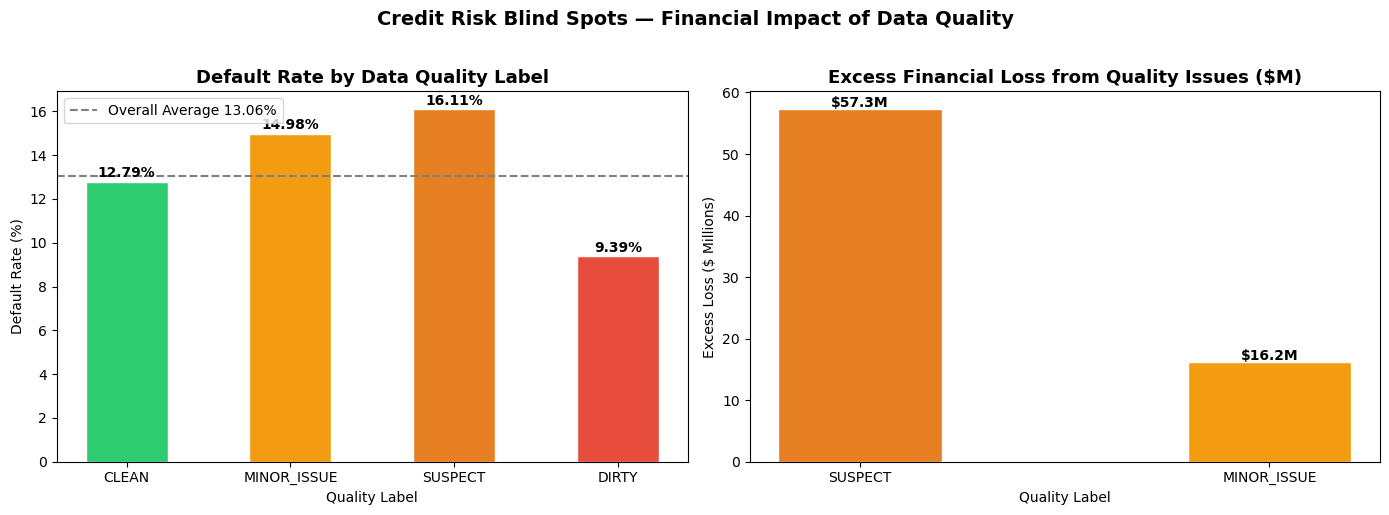

In [35]:
# ================================================
# VISUALIZATION — Default Rate by Quality Label
# ================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — Default rate by quality label
colors = {
    'CLEAN'      : '#2ecc71',
    'MINOR_ISSUE': '#f39c12',
    'SUSPECT'    : '#e67e22',
    'DIRTY'      : '#e74c3c'
}

order = ['CLEAN', 'MINOR_ISSUE', 'SUSPECT', 'DIRTY']
rates = default_by_quality.set_index(
    'quality_label')['default_rate'].reindex(order)
bar_colors = [colors[l] for l in order]

axes[0].bar(order, rates, color=bar_colors, edgecolor='white', width=0.5)
axes[0].set_title('Default Rate by Data Quality Label',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Quality Label')
axes[0].set_ylabel('Default Rate (%)')
axes[0].axhline(y=13.06, color='gray', linestyle='--',
                label='Overall Average 13.06%')
axes[0].legend()
for i, (label, val) in enumerate(zip(order, rates)):
    axes[0].text(i, val + 0.2, f'{val}%', ha='center', fontweight='bold')

# Chart 2 — Excess loss by quality label
excess = {
    'SUSPECT'    : 57319861,
    'MINOR_ISSUE': 16214386,
}
axes[1].bar(excess.keys(), 
            [v/1e6 for v in excess.values()],
            color=['#e67e22', '#f39c12'],
            edgecolor='white', width=0.4)
axes[1].set_title('Excess Financial Loss from Quality Issues ($M)',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Quality Label')
axes[1].set_ylabel('Excess Loss ($ Millions)')
for i, (label, val) in enumerate(excess.items()):
    axes[1].text(i, val/1e6 + 0.3, f'${val/1e6:.1f}M',
                 ha='center', fontweight='bold')

plt.suptitle('Credit Risk Blind Spots — Financial Impact of Data Quality',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [37]:
# ================================================
# STRATIFIED SAMPLE — 200K records
# Keeps proportions of quality labels intact
# ================================================

df_sample = df_scored[export_cols].groupby(
    'quality_label', group_keys=False
).apply(lambda x: x.sample(
    frac=0.09, random_state=42
))

print("Sample distribution:")
print(df_sample['quality_label'].value_counts())
print(f"\nTotal sampled records: {len(df_sample):,}")

df_sample.to_csv(
    'D:/CDAC_DBDA/Analysis_Project_Resume/Project_2/loans_final_scored.csv',
    index=False
)

print("✅ Sampled dataset saved")

C:\Users\rohit\AppData\Local\Temp\ipykernel_18288\2756406549.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(lambda x: x.sample(


Sample distribution:
quality_label
CLEAN          184828
SUSPECT         12957
MINOR_ISSUE      5384
DIRTY             295
Name: count, dtype: int64

Total sampled records: 203,464
✅ Sampled dataset saved
